In [ ]:
import pandas as pd
import numpy as np

def run_telecom_analysis(file_path):
    df = pd.read_csv(file_path)

    # Define High-Value Customers (HVC)
    # Average recharge amount in June (6) and July (7)
    df['avg_rech_6_7'] = (df['total_rech_amt_6'] + df['total_rech_amt_7']) / 2

    # Filter top 30% customers (High Value)
    threshold = df['avg_rech_6_7'].quantile(0.7)
    hvc_df = df[df['avg_rech_6_7'] >= threshold].copy()

    # Define Churn (Business Logic)
    hvc_df['total_usage_9'] = hvc_df['total_og_mou_9'] + hvc_df['total_ic_mou_9'] + hvc_df['vol_2g_mb_9'] + hvc_df['vol_3g_mb_9']
    hvc_df['churn'] = hvc_df['total_usage_9'].apply(lambda x: 1 if x == 0 else 0)

    # Analysis: Why are they leaving?
    hvc_df['mou_drop_ratio'] = (hvc_df['total_og_mou_8'] - hvc_df['total_og_mou_7']) / (hvc_df['total_og_mou_7'] + 1)

    churners = hvc_df[hvc_df['churn'] == 1]
    non_churners = hvc_df[hvc_df['churn'] == 0]

    print(f"--- Telecom Business Intelligence Report ---")
    print(f"High-Value Customers Analyzed: {len(hvc_df)}")
    print(f"Churn Rate among High-Value: {(len(churners)/len(hvc_df))*100:.2f}%")
    print("-" * 45)
    print(f"Avg MOU Drop for Churners: {churners['mou_drop_ratio'].mean():.2f}")
    print(f"Avg MOU Drop for Loyalists: {non_churners['mou_drop_ratio'].mean():.2f}")

    # Strategic Alert: Identify "At-Risk" Customers (Still active but usage crashed)
    at_risk = hvc_df[(hvc_df['churn'] == 0) & (hvc_df['mou_drop_ratio'] < -0.5)]
    print(f"ALERT: {len(at_risk)} customers are currently 'At-Risk' (50%+ usage drop).")

# Execute
run_telecom_analysis('telecom_churn_data.csv')

--- Telecom Business Intelligence Report ---
High-Value Customers Analyzed: 30011
Churn Rate among High-Value: 8.64%
---------------------------------------------
Avg MOU Drop for Churners: 0.95
Avg MOU Drop for Loyalists: 4.80
ALERT: 3978 customers are currently 'At-Risk' (50%+ usage drop).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('telecom_churn_data.csv')

# 1. High-Value Customer (HVC) Filter (Top 30% based on month 6 & 7 recharge)
df['avg_rech_6_7'] = (df['total_rech_amt_6'].fillna(0) + df['total_rech_amt_7'].fillna(0)) / 2
threshold = df['avg_rech_6_7'].quantile(0.7)
hvc_df = df[df['avg_rech_6_7'] >= threshold].copy()

# 2. Derive Churn (Month 9 usage = 0)
hvc_df['total_usage_9'] = (hvc_df['total_og_mou_9'].fillna(0) +
                           hvc_df['total_ic_mou_9'].fillna(0) +
                           hvc_df['vol_2g_mb_9'].fillna(0) +
                           hvc_df['vol_3g_mb_9'].fillna(0))
hvc_df['churn'] = hvc_df['total_usage_9'].apply(lambda x: 1 if x == 0 else 0)





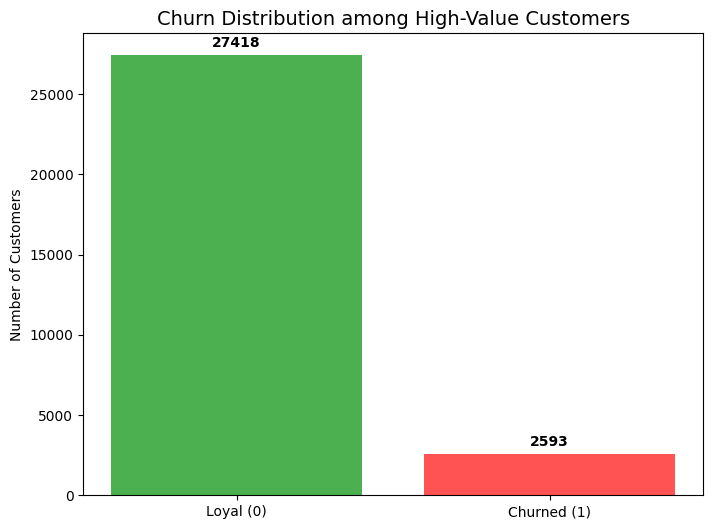

In [ ]:
# --- Plot 1: Churn Distribution ---
plt.figure(figsize=(8, 6))
churn_counts = hvc_df['churn'].value_counts()
plt.bar(['Loyal (0)', 'Churned (1)'], churn_counts.values, color=['#4CAF50', '#FF5252'])
plt.title('Churn Distribution among High-Value Customers', fontsize=14)
plt.ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')
plt.savefig('churn_dist.png')


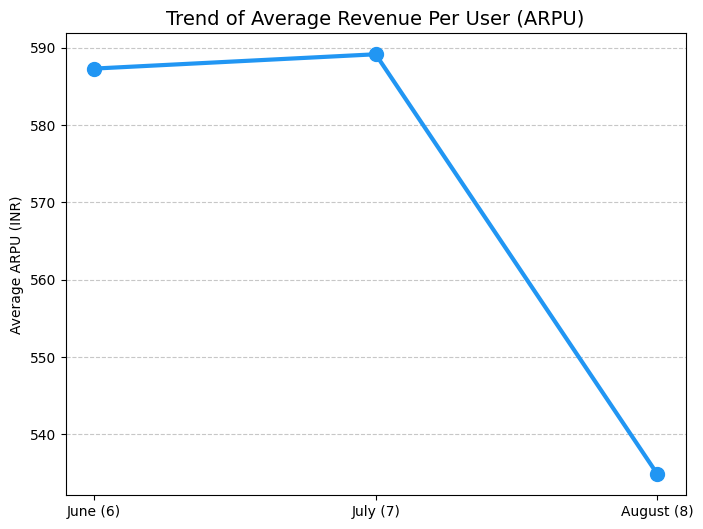

In [ ]:
# --- Plot 2: ARPU Trend (Month 6 to 8) ---
avg_arpu = [hvc_df['arpu_6'].mean(), hvc_df['arpu_7'].mean(), hvc_df['arpu_8'].mean()]
months = ['June (6)', 'July (7)', 'August (8)']

plt.figure(figsize=(8, 6))
plt.plot(months, avg_arpu, marker='o', linestyle='-', color='#2196F3', linewidth=3, markersize=10)
plt.title('Trend of Average Revenue Per User (ARPU)', fontsize=14)
plt.ylabel('Average ARPU (INR)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('arpu_trend_plot.png')


Graphs processed.


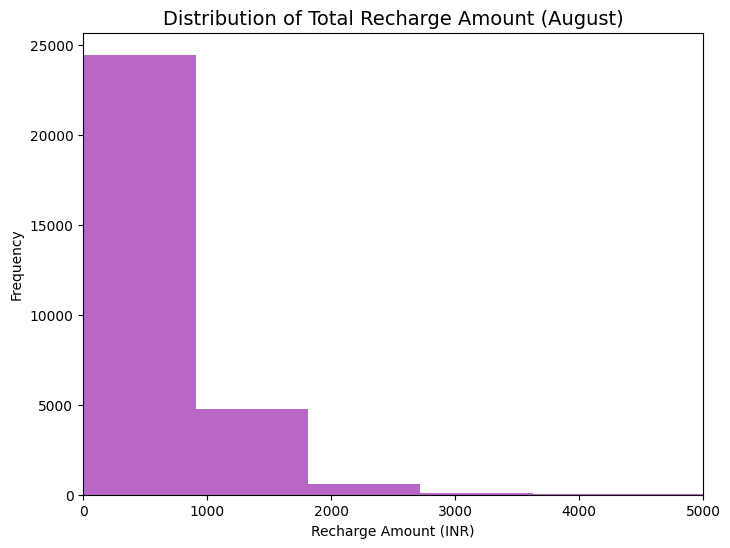

In [ ]:
# --- Plot 3: Distribution of Recharge Amounts (Month 8) ---
plt.figure(figsize=(8, 6))
plt.hist(hvc_df['total_rech_amt_8'].dropna(), bins=50, color='#9C27B0', alpha=0.7)
plt.title('Distribution of Total Recharge Amount (August)', fontsize=14)
plt.xlabel('Recharge Amount (INR)')
plt.ylabel('Frequency')
plt.xlim(0, 5000)
plt.savefig('rech_amt_dist.png')

print("Graphs processed.")

In [ ]:
df.columns


Index(['mobile_number', 'circle_id', 'loc_og_t2o_mou', 'std_og_t2o_mou',
       'loc_ic_t2o_mou', 'last_date_of_month_6', 'last_date_of_month_7',
       'last_date_of_month_8', 'last_date_of_month_9', 'arpu_6',
       ...
       'fb_user_6', 'fb_user_7', 'fb_user_8', 'fb_user_9', 'aon', 'aug_vbc_3g',
       'jul_vbc_3g', 'jun_vbc_3g', 'sep_vbc_3g', 'avg_rech_6_7'],
      dtype='object', length=227)